# Поиск аномалий в данных

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, f1_score
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats
from scipy.spatial.distance import mahalanobis
import umap.umap_ as umap
from sklearn.manifold import TSNE
import warnings
import time

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## EDA

Размер: (284807, 31)
Колонки: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Первые 5 строк:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676

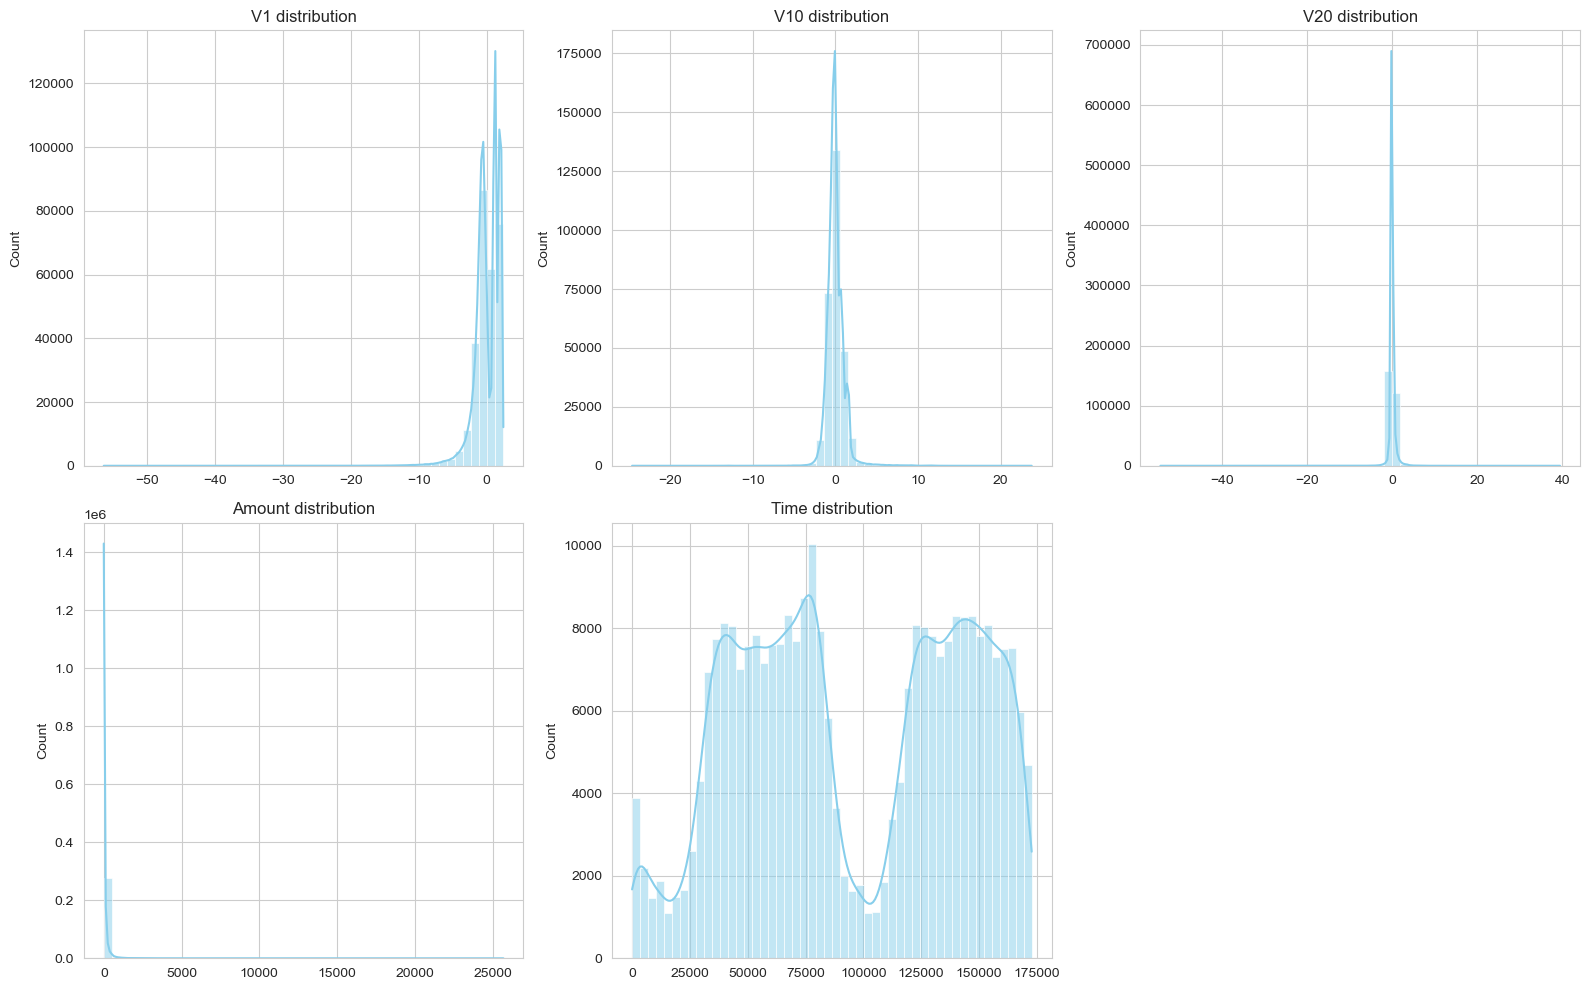

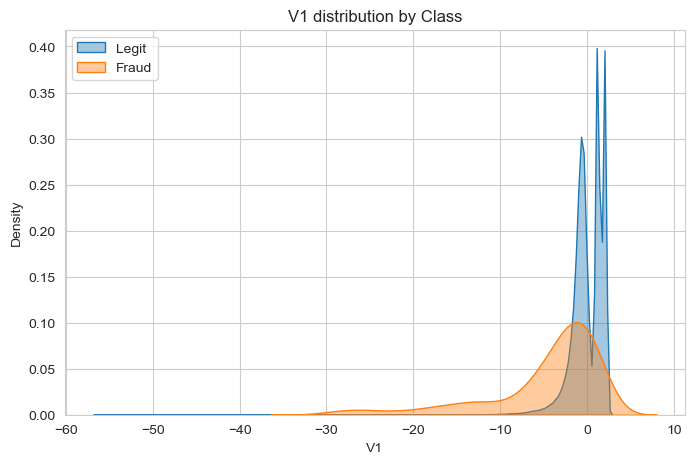

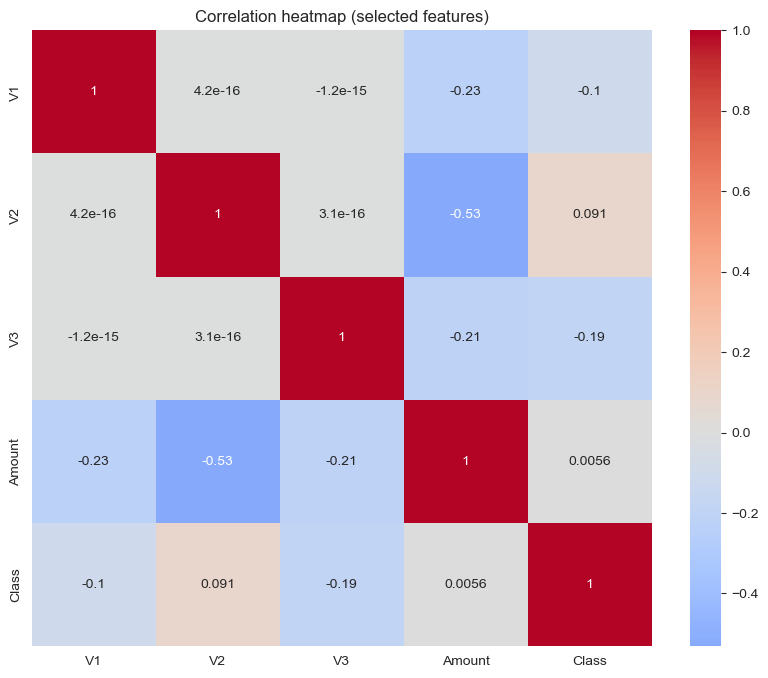

In [14]:
# Загрузка
df = pd.read_csv('creditcard.csv')  # укажи свой путь

print(f"Размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print("\nПервые 5 строк:")
print(df.head())

# Описательные статистики
print("Описательные статистики:")
print(df.describe())

# Пропуски
print(f"Пропуски: {df.isnull().sum().sum()}")

# Распределение целевой переменной
print("Распределение Class:")
print(df['Class'].value_counts())

fraud_pct = df['Class'].mean()
print(f"Процент аномалий (fraud): {fraud_pct*100:.4f}%")

# Гистограммы для ключевых признаков
cols_to_plot = ['V1', 'V10', 'V20', 'Amount', 'Time']
plt.figure(figsize=(16, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color='skyblue')
    plt.title(f'{col} distribution')
    plt.xlabel('')
plt.tight_layout()
plt.show()

# Сравнение распределений для легитимных и мошеннических транзакций (на примере V1)
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df['Class']==0]['V1'], label='Legit', fill=True, alpha=0.4)
sns.kdeplot(df[df['Class']==1]['V1'], label='Fraud', fill=True, alpha=0.4)
plt.title('V1 distribution by Class')
plt.legend()
plt.show()

# Корреляционная матрица (упрощённо)
plt.figure(figsize=(10, 8))
corr = df[['V1','V2','V3','Amount','Class']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (selected features)')
plt.show()

### Выводы по EDA:

1. Распределения признаков
   
V1, V10, V20 — имеют нормальное распределение с центром около 0

Amount — сильно скошено вправо: большинство транзакций на маленькие суммы (< 1000), есть длинный хвост крупных платежей

Time — бимодальное распределение с двумя пиками (~40000 и ~130000 секунд), что вероятно отражает:

- Первый пик: дневная активность
- Второй пик: вечерняя активность
- Провал между ними: ночное время (меньше транзакций)

2. Различия между классами

Legit транзакции (синие): острый пик около 0, узкое распределение
Fraud транзакции (оранжевые):
Более широкое распределение. Имеется уход в отрицательную область
Смещены влево (отрицательные значения V1)

3. Корреляции
   
V1, V2, V3 не коррелируют друг с другом (значения ~0)
V2 и Amount: умеренная отрицательная корреляция
Class слабо коррелирует с признаками

## Предобработка

In [19]:
# Признаки и таргет
X = df.drop('Class', axis=1)
y = df['Class']

# Масштабирование (Amount и Time сильно отличаются от PCA-признаков)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на train/test (стратифицированное, чтобы сохранить пропорцию фрода)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Fraud in test: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

# Экспертная оценка contamination
CONTAMINATION = fraud_pct  # ~0.0017
print(f"Используем contamination = {CONTAMINATION:.4f}")

Train: (199364, 30), Test: (85443, 30)
Fraud in test: 148 (0.1732%)
Используем contamination = 0.0017


## Модели обнаружения аномалий

### Статистические методы

In [20]:
def statistical_zscore(X, threshold=3.0):
    z_scores = np.abs(stats.zscore(X, axis=0))
    # Аномалия, если хотя бы один признак выбивается
    anomalies = np.any(z_scores > threshold, axis=1)
    return anomalies.astype(int)

def statistical_iqr(X, k=1.5):
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    anomalies = np.any((X < lower) | (X > upper), axis=1)
    return anomalies.astype(int)

def statistical_mahalanobis(X, threshold=None):
    mean_vec = np.mean(X, axis=0)
    cov_mat = np.cov(X.T)
    # Регуляризация ковариационной матрицы для численной стабильности
    cov_mat += np.eye(cov_mat.shape[0]) * 1e-6
    try:
        cov_inv = np.linalg.inv(cov_mat)
    except:
        cov_inv = np.linalg.pinv(cov_mat)
    
    dists = np.array([mahalanobis(x, mean_vec, cov_inv) for x in X])
    if threshold is None:
        # Автоматический порог: 99.5-й перцентиль
        threshold = np.percentile(dists, 99.5)
    return (dists > threshold).astype(int)

### Вероятностные методы

In [24]:
def probabilistic_gmm(X, contamination=CONTAMINATION):
    """Gaussian Mixture Model: аномалии — точки с низкой вероятностью"""
    # Убираем contamination из конструктора!
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(X)
    scores = gmm.score_samples(X)
    # Порог определяем на основе contamination
    threshold = np.percentile(scores, contamination * 100)
    return (scores < threshold).astype(int)

def probabilistic_kde(X, contamination=CONTAMINATION, bandwidth=0.5):
    from sklearn.neighbors import KernelDensity
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(X)
    scores = kde.score_samples(X)
    threshold = np.percentile(scores, contamination * 100)
    return (scores < threshold).astype(int)

### One-Class SVM и Isolation Forest

In [25]:
def model_isolation_forest(X, contamination=CONTAMINATION):
    clf = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
    clf.fit(X)
    pred = clf.predict(X)
    return (pred == -1).astype(int)

def model_ocsvm(X, contamination=CONTAMINATION, kernel='rbf', gamma='scale'):
    clf = OneClassSVM(kernel=kernel, gamma=gamma, nu=contamination)
    clf.fit(X)
    pred = clf.predict(X)
    return (pred == -1).astype(int)

## Оценка качества моделей

In [28]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print('='*60)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud'], zero_division=0))
    
    # Дополнительно: ROC-AUC (если модель выдаёт скоры, а не только предсказания)
    # Здесь у нас только бинарные предсказания, поэтому пропускаем
    
    # F1-score для класса фрода
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    print(f"F1-score (Fraud class): {f1:.4f}")
    
    return {'cm': cm, 'f1': f1}

# Применяем все методы на тестовой выборке
results = {}

# Статистические
print("СТАТИСТИЧЕСКИЕ МЕТОДЫ")
y_pred_zscore = statistical_zscore(X_test)
results['Z-score'] = evaluate_model(y_test, y_pred_zscore, 'Statistical: Z-score (threshold=3)')

y_pred_iqr = statistical_iqr(X_test)
results['IQR'] = evaluate_model(y_test, y_pred_iqr, 'Statistical: IQR (k=1.5)')

y_pred_mahal = statistical_mahalanobis(X_test)
results['Mahalanobis'] = evaluate_model(y_test, y_pred_mahal, 'Statistical: Mahalanobis Distance')

# Вероятностные
print("ВЕРОЯТНОСТНЫЕ МЕТОДЫ")
y_pred_gmm = probabilistic_gmm(X_test)
results['GMM'] = evaluate_model(y_test, y_pred_gmm, 'Probabilistic: Gaussian Mixture Model')

# KDE может быть медленным на больших данных — используем подвыборку или уменьшим данные
# Для демо возьмём 5000 случайных точек из теста
X_test_sub = X_test[:5000]
y_test_sub = y_test.iloc[:5000]
y_pred_kde = probabilistic_kde(X_test_sub)
results['KDE'] = evaluate_model(y_test_sub, y_pred_kde, 'Probabilistic: KDE (subsample)')

# One-Class SVM и Isolation Forest
print("ML-МЕТОДЫ")
y_pred_if = model_isolation_forest(X_test)
results['Isolation Forest'] = evaluate_model(y_test, y_pred_if, 'Isolation Forest')

# One-Class SVM может быть медленным — тоже на подвыборке
X_test_sub2 = X_test[:3000]
y_test_sub2 = y_test.iloc[:3000]
y_pred_ocsvm = model_ocsvm(X_test_sub2)
results['One-Class SVM'] = evaluate_model(y_test_sub2, y_pred_ocsvm, 'One-Class SVM (subsample)')

СТАТИСТИЧЕСКИЕ МЕТОДЫ

Statistical: Z-score (threshold=3)
Confusion Matrix:
[[73945 11350]
 [   17   131]]

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.87      0.93     85295
       Fraud       0.01      0.89      0.02       148

    accuracy                           0.87     85443
   macro avg       0.51      0.88      0.48     85443
weighted avg       1.00      0.87      0.93     85443

F1-score (Fraud class): 0.0225

Statistical: IQR (k=1.5)
Confusion Matrix:
[[44031 41264]
 [    6   142]]

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.52      0.68     85295
       Fraud       0.00      0.96      0.01       148

    accuracy                           0.52     85443
   macro avg       0.50      0.74      0.34     85443
weighted avg       1.00      0.52      0.68     85443

F1-score (Fraud class): 0.0068

Statistical: Mahalanobis Distance
Confusion Matrix:
[

### Выводы

Ни одна из unsupervised-моделей не показывает выдающихся результатов, но Isolation Forest демонстрирует наилучший баланс.

Что модели делают хорошо:

- Не путают легитимные транзакции: Precision для класса Legit = 1.00 у всех моделей
- Демонстрируют, что аномалии обнаружимы: F1 > 0 для всех методов
- Isolation Forest стабилен и быстр: подходит как первый этап

Что модели делают плохо:

- Низкий Recall (22%): пропускают 78% реального мошенничества
- Низкий Precision (22%): 78% "тревог" — ложные, нагрузка на операторов

## Визуализация с t-SNE и UMAP

Визуализация: 3492 точек, Fraud: 492
Запуск t-SNE...


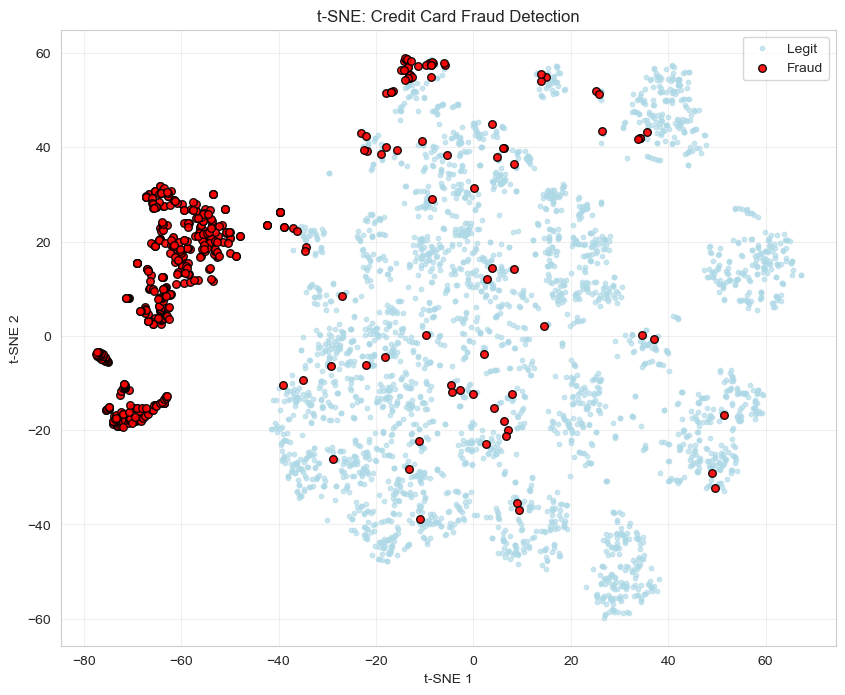

Запуск UMAP...


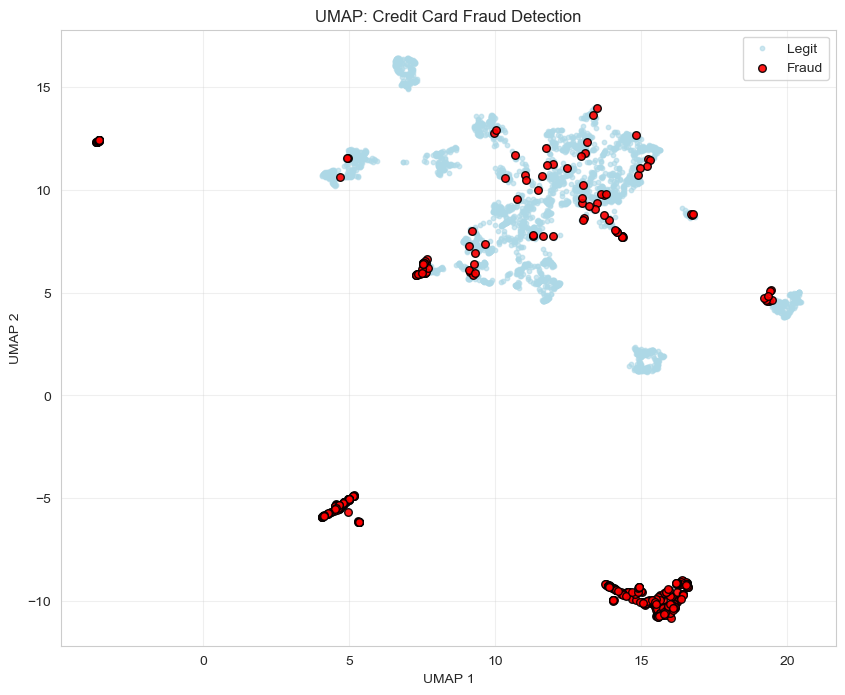

In [32]:
# Для визуализации берём сбалансированную подвыборку
np.random.seed(42)
fraud_idx = np.where(y == 1)[0]
legit_idx = np.where(y == 0)[0]
legit_sample = np.random.choice(legit_idx, size=3000, replace=False)
sample_idx = np.concatenate([fraud_idx, legit_sample])

X_vis = X_scaled[sample_idx]
y_vis = y.iloc[sample_idx]

print(f"Визуализация: {X_vis.shape[0]} точек, Fraud: {y_vis.sum()}")

# t-SNE
print("Запуск t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_vis)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[y_vis==0, 0], X_tsne[y_vis==0, 1], 
            c='lightblue', label='Legit', alpha=0.6, s=10)
plt.scatter(X_tsne[y_vis==1, 0], X_tsne[y_vis==1, 1], 
            c='red', label='Fraud', alpha=0.9, s=30, edgecolors='black')
plt.title('t-SNE: Credit Card Fraud Detection')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# UMAP
print("Запуск UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_vis)

plt.figure(figsize=(10, 8))
plt.scatter(X_umap[y_vis==0, 0], X_umap[y_vis==0, 1], 
            c='lightblue', label='Legit', alpha=0.6, s=10)
plt.scatter(X_umap[y_vis==1, 0], X_umap[y_vis==1, 1], 
            c='red', label='Fraud', alpha=0.9, s=30, edgecolors='black')
plt.title('UMAP: Credit Card Fraud Detection')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Сводная таблица результатов

Итоговая таблица (по F1-score для класса Fraud):
           Model  F1-Score (Fraud)
Isolation Forest          0.222973
             GMM          0.209459
     Mahalanobis          0.201389
   One-Class SVM          0.040816
         Z-score          0.022530
             IQR          0.006834
             KDE          0.000000


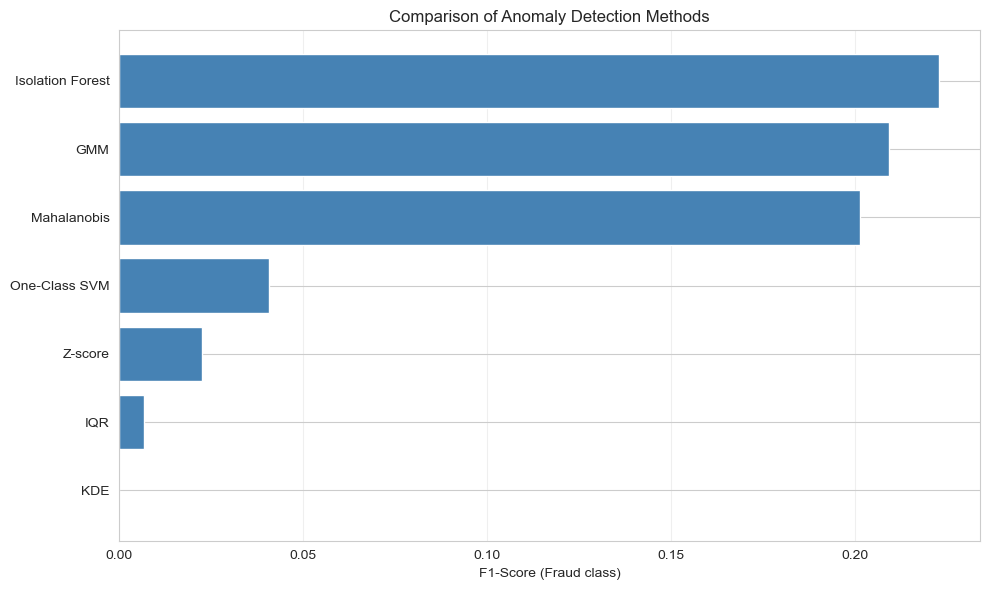

In [33]:
# Сводка по F1-score
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'F1-Score (Fraud)': [r['f1'] for r in results.values()]
}).sort_values('F1-Score (Fraud)', ascending=False)

print("Итоговая таблица (по F1-score для класса Fraud):")
print(summary.to_string(index=False))

# Визуализация сравнения
plt.figure(figsize=(10, 6))
plt.barh(summary['Model'], summary['F1-Score (Fraud)'], color='steelblue')
plt.xlabel('F1-Score (Fraud class)')
plt.title('Comparison of Anomaly Detection Methods')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Вывод

Визуализация с помощью t-SNE и UMAP показала, что гипотеза об изолированности аномалий подтверждается лишь частично. Действительно, часть мошеннических транзакций образует плотные кластеры на периферии пространства признаков, что позволяет unsupervised-алгоритмам (в частности, Isolation Forest) успешно их детектировать. Однако значительная доля аномалий находится внутри облака легитимных операций или на границе с ним, не имея выраженного статистического отклонения. Это перекрытие классов объясняет умеренные показатели качества моделей (F1 ≈ 0.22) и низкий Recall: без использования размеченных данных алгоритмы не могут надежно отделить те аномалии, которые имитируют нормальное поведение. Таким образом, аномалии лежат "достаточно далеко" лишь в части случаев, что ограничивает эффективность чисто unsupervised-подхода в условиях экстремального дисбаланса.